# Unit Economics of an AI Agent

How do you work out the **per-request AWS cost** of an AI agent workload?

This notebook walks through a PDF-translation agent one service at a time, then
adds them up. Every rate lives in [`cost.py`](cost.py) — edit it there for your region.

The request flows through:

1. **Textract** — read text blocks from the PDF (priced per page)
2. **Bedrock (Nova Lite)** — translate the blocks (priced per token)
3. **Lambda** — the compute running each step (priced per GB-second)
4. **S3** — storing/reading files (priced per request)
5. **AgentCore Gateway + Runtime** — the agent host (estimates)

In [1]:
import cost

# The rates we're working with (USD)
print(f"Textract, per page:       ${cost.TEXTRACT_COST_PER_PAGE}")
print(f"Bedrock in,  per 1K tok:  ${cost.NOVA_LITE_INPUT_COST_PER_1K}")
print(f"Bedrock out, per 1K tok:  ${cost.NOVA_LITE_OUTPUT_COST_PER_1K}")
print(f"Lambda, per GB-second:    ${cost.LAMBDA_COST_PER_GB_SECOND}")
print(f"S3 GET / PUT:             ${cost.S3_GET_COST} / ${cost.S3_PUT_COST}")

Textract, per page:       $0.0015
Bedrock in,  per 1K tok:  $6e-05
Bedrock out, per 1K tok:  $0.00024
Lambda, per GB-second:    $1.66667e-05
S3 GET / PUT:             $4e-07 / $5e-06


## Describe one request

A `Request` bundles everything about a single request that drives its cost:
how many pages, how many tokens, how long Lambda ran, and so on.

In [2]:
req = cost.Request(
    pages=3,
    input_tokens=4000,
    output_tokens=4000,
    lambda_memory_mb=1024,
    lambda_duration_ms=3000,
)
req

Request(pages=3, input_tokens=4000, output_tokens=4000, model='nova-lite', lambda_memory_mb=1024, lambda_duration_ms=3000, s3_get_requests=4, s3_put_requests=3, gateway_invocations=3)

## 1. Textract — priced per page

The simplest component: `pages × rate`.

In [3]:
textract = req.pages * cost.TEXTRACT_COST_PER_PAGE
print(f"{req.pages} pages × ${cost.TEXTRACT_COST_PER_PAGE} = ${textract:.6f}")

3 pages × $0.0015 = $0.004500


## 2. Bedrock — priced per token

Input and output tokens are billed at **different** rates (output is pricier).
Note the `/ 1000` — rates are quoted per 1,000 tokens.

In [4]:
bedrock = (
    req.input_tokens / 1000 * cost.NOVA_LITE_INPUT_COST_PER_1K
    + req.output_tokens / 1000 * cost.NOVA_LITE_OUTPUT_COST_PER_1K
)
print(f"in:  {req.input_tokens} tok → ${req.input_tokens / 1000 * cost.NOVA_LITE_INPUT_COST_PER_1K:.6f}")
print(f"out: {req.output_tokens} tok → ${req.output_tokens / 1000 * cost.NOVA_LITE_OUTPUT_COST_PER_1K:.6f}")
print(f"bedrock total = ${bedrock:.6f}")

in:  4000 tok → $0.000240
out: 4000 tok → $0.000960
bedrock total = $0.001200


## 3. Lambda — priced per GB-second

This is the one that trips people up. Lambda bills **GB-seconds**: the memory you
allocate (in GB) times how long the function ran (in seconds).

$$\text{GB-seconds} = \frac{\text{memory MB}}{1024} \times \frac{\text{duration ms}}{1000}$$

In [5]:
gb_seconds = (req.lambda_memory_mb / 1024) * (req.lambda_duration_ms / 1000)
lambda_cost = gb_seconds * cost.LAMBDA_COST_PER_GB_SECOND
print(f"{req.lambda_memory_mb} MB for {req.lambda_duration_ms} ms = {gb_seconds:.4f} GB-s")
print(f"{gb_seconds:.4f} GB-s × ${cost.LAMBDA_COST_PER_GB_SECOND} = ${lambda_cost:.8f}")

1024 MB for 3000 ms = 3.0000 GB-s
3.0000 GB-s × $1.66667e-05 = $0.00005000


## 4. S3, Gateway, Runtime — per request

The remaining pieces are flat per-request or per-invocation charges.

In [6]:
s3 = req.s3_get_requests * cost.S3_GET_COST + req.s3_put_requests * cost.S3_PUT_COST
gateway = req.gateway_invocations * cost.GATEWAY_COST_PER_INVOCATION
runtime = cost.RUNTIME_COST_ESTIMATE
print(f"S3:      ${s3:.8f}")
print(f"Gateway: ${gateway:.6f}")
print(f"Runtime: ${runtime:.6f}")

S3:      $0.00001660
Gateway: $0.000300
Runtime: $0.000200


## Add it all up

`calculate_cost()` does exactly the arithmetic above and returns an itemised dict.

In [7]:
costs = cost.calculate_cost(req)
print(cost.format_report(costs))


Per-request cost breakdown
Textract               $0.004500     3 pages
Bedrock (nova-lite)    $0.001200     4000 in / 4000 out tokens
Lambda                 $0.000050     3.0 GB-s
S3                     $0.000017     4 GET / 3 PUT
AgentCore Gateway      $0.000300     3 invocations (est.)
AgentCore Runtime      $0.000200     estimate
----------------------------------
TOTAL                  $0.006267    



## Scale it: what does this cost at volume?

One request is fractions of a cent — the interesting question is the monthly bill.

In [8]:
per_request = costs["totalEstimated"]
for n in (1_000, 100_000, 1_000_000):
    print(f"{n:>10,} requests/mo  →  ${per_request * n:,.2f}")

     1,000 requests/mo  →  $6.27
   100,000 requests/mo  →  $626.70
 1,000,000 requests/mo  →  $6,267.00


## Where does the money go?

Breaking the total into shares shows which service to optimise first.

In [9]:
total = costs["totalEstimated"]
components = ["textract", "bedrock", "lambda", "s3", "agentcoreGateway", "agentcoreRuntime"]
for name in components:
    part = costs[name]["total"]
    bar = "█" * int(round(part / total * 40))
    print(f"{name:<18} {part/total*100:5.1f}%  {bar}")

textract            71.8%  █████████████████████████████
bedrock             19.1%  ████████
lambda               0.8%  
s3                   0.3%  
agentcoreGateway     4.8%  ██
agentcoreRuntime     3.2%  █


## Try your own numbers

Change the inputs below and re-run to see the effect.

In [10]:
my_req = cost.Request(pages=10, input_tokens=12_000, output_tokens=9_000)
print(cost.format_report(cost.calculate_cost(my_req)))


Per-request cost breakdown
Textract               $0.015000     10 pages
Bedrock (nova-lite)    $0.002880     12000 in / 9000 out tokens
Lambda                 $0.000050     3.0 GB-s
S3                     $0.000017     4 GET / 3 PUT
AgentCore Gateway      $0.000300     3 invocations (est.)
AgentCore Runtime      $0.000200     estimate
----------------------------------
TOTAL                  $0.018447    



## Charts

The ASCII bars are fine for a terminal; here are real charts (matplotlib).
Requires the `charts.py` module in this folder.

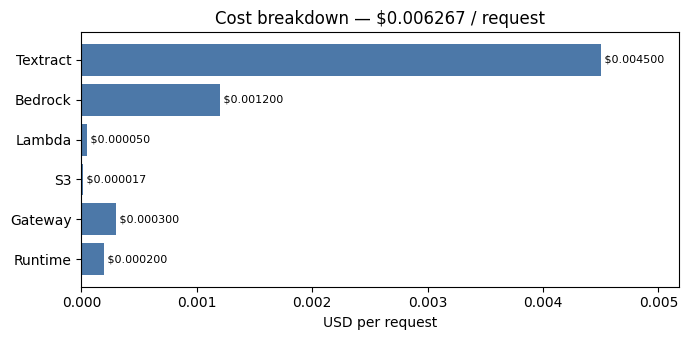

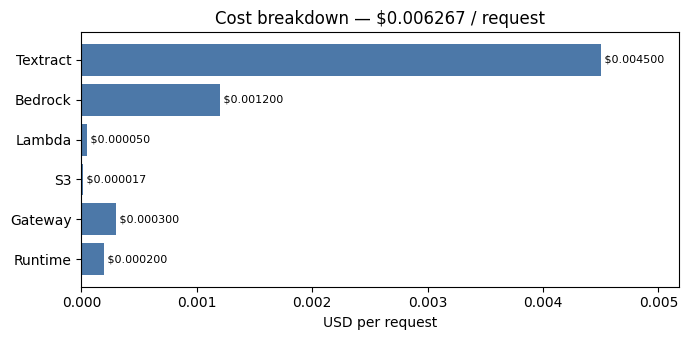

In [11]:
import charts
charts.cost_breakdown(costs)

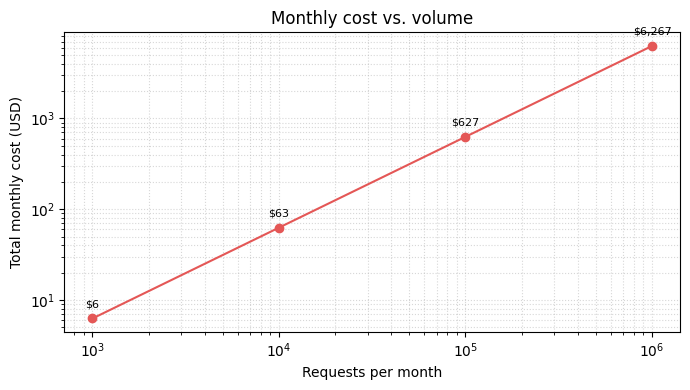

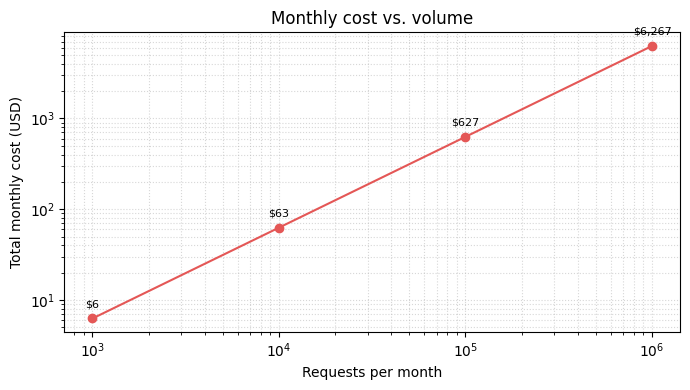

In [12]:
charts.monthly_projection(costs)

## The big one: model choice

Everything above priced Nova Lite. But the model you pick swamps the
infrastructure cost. Same request, every model:

In [13]:
rows = cost.compare_models(req)
print(cost.format_comparison(rows))


Same request, different models
model                bedrock     total/req
--------------------------------------------
nova-micro      $  0.000700$    0.005767
nova-lite       $  0.001200$    0.006267
nova-pro        $  0.016000$    0.021067
claude-haiku    $  0.019200$    0.024267
claude-sonnet   $  0.072000$    0.077067



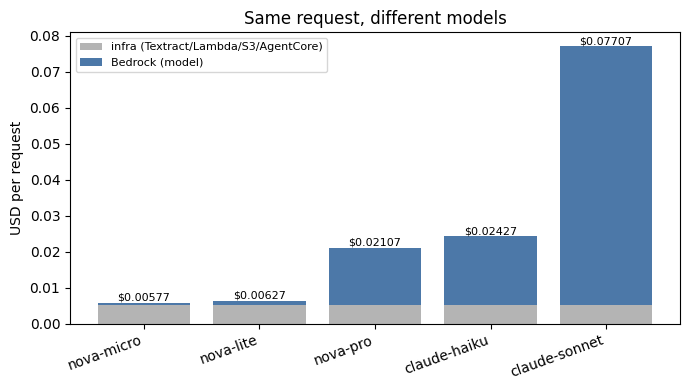

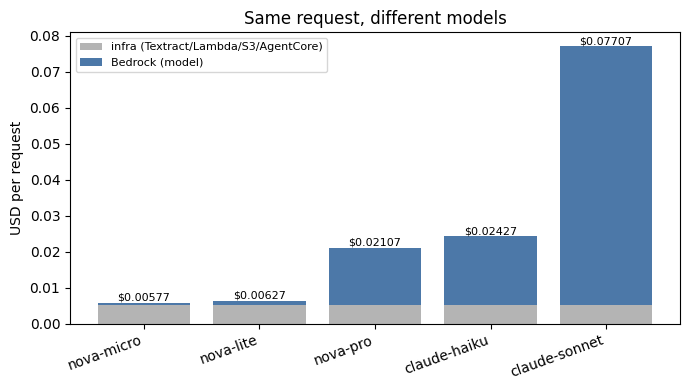

In [14]:
charts.model_comparison(rows)

Notice the grey (infra) bar barely changes — the whole spread is the
model. Choosing Sonnet over Nova Lite is ~12x the per-request cost here.

## Unit economics: are we making money?

Cost is only half the story. Pick a price and see the margin and break-even
volume against some fixed monthly overhead.

In [15]:
m = cost.margin(
    cost_per_request=costs["totalEstimated"],
    price_per_request=0.02,   # what you charge per translation
    fixed_monthly=100.0,      # fixed overhead to cover
)
print(cost.format_margin(m))


Unit economics
Cost / request    $0.006267
Price / request   $0.020000
Profit / request  $0.013733
Gross margin      68.66%
Fixed monthly     $100.00
Break-even        7,282 requests/mo

